
Y-band fit parameters (a, b): [ 1.66593073 -0.89495883]


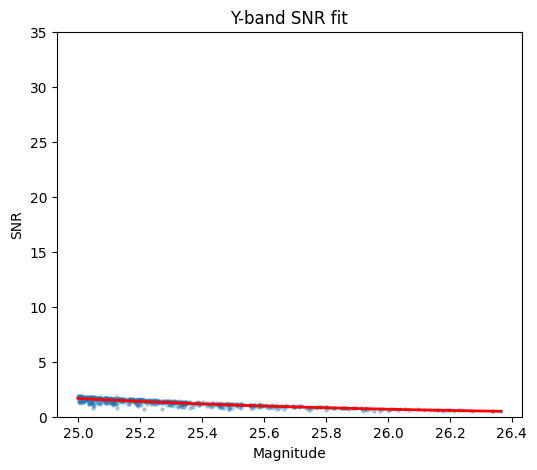

1σ depth = 25.57
2σ depth = 24.80
3σ depth = 24.34
4σ depth = 24.02
5σ depth = 23.77

i-band fit parameters (a, b): [22.71835109 -0.77387407]


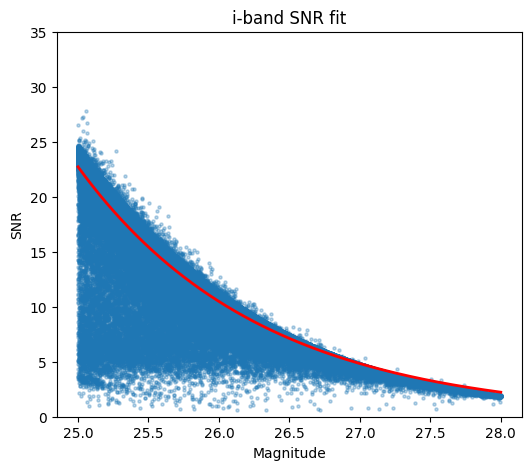

1σ depth = 29.04
2σ depth = 28.14
3σ depth = 27.62
4σ depth = 27.24
5σ depth = 26.96

z-band fit parameters (a, b): [19.65893349 -0.82901371]


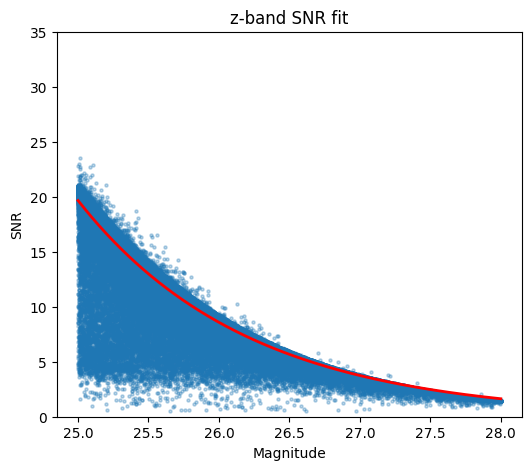

1σ depth = 28.59
2σ depth = 27.76
3σ depth = 27.27
4σ depth = 26.92
5σ depth = 26.65

Final depth summary (mag):
1σ:  Y=25.57   i=29.04   z=28.59
2σ:  Y=24.80   i=28.14   z=27.76
3σ:  Y=24.34   i=27.62   z=27.27
4σ:  Y=24.02   i=27.24   z=26.92
5σ:  Y=23.77   i=26.96   z=26.65


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, brentq

# ============================================================
# File paths
# ============================================================
i_file  = "/Users/aishwarya/Desktop/new_cdfs/cat/LBG_I_CDFS_depth.cat"
z_file  = "/Users/aishwarya/Desktop/new_cdfs/cat/LBG_Z_CDFS_depth.cat"
y_file  = "/Users/aishwarya/Desktop/new_cdfs/cat/LBG_Y_CDFS_depth.cat"

# ============================================================
# Load catalogs
# ============================================================
colnames = ["ID", "X", "Y", "RA", "DEC",
            "MAG_APER", "MAGERR_APER",
            "MAG_AUTO", "MAGERR_AUTO",
            "FLAGS", "ISOAREA_IMAGE"]


i_df = pd.read_csv(i_file, sep=r"\s+", comment="#", names=colnames)
z_df = pd.read_csv(z_file, sep=r"\s+", comment="#", names=colnames)
y_df = pd.read_csv(y_file, sep=r"\s+", comment="#", names=colnames)

# ============================================================
# Zero points
# ============================================================
ZP_i, ZP_z, ZP_y = 31.354, 31.524, 30.3382
ZPe_i, ZPe_z, ZPe_y = 0.004, 0.004, 0.009

for df, zp, zpe in zip([i_df, z_df, y_df], [ZP_i, ZP_z, ZP_y], [ZPe_i, ZPe_z, ZPe_y]):
    df["MAG_CAL"] = df["MAG_APER"] + zp
    df["MAGERR_CAL"] = np.sqrt(df["MAGERR_APER"]**2 + zpe**2)


# Exponential SNR model 
# SNR(m) = a * exp(b*(m - k))


def snr_model(m, a, b):
    return a * np.exp(b * (m - 25))


def fit_snr_exponential(mag, magerr, bandname):

    # Clean data
    valid = np.isfinite(mag) & np.isfinite(magerr) & (mag < 50)
    mag = mag[valid]
    magerr = magerr[valid]

    # Convert to SNR 
    snr = (2.5 / np.log(10)) / magerr

   
    mask = (0.5 < snr) & (snr < 90)
    mag = mag[mask]
    snr = snr[mask]

  
    fit_mask = (mag > 25) & (mag < 28)
    mag = mag[fit_mask]
    snr = snr[fit_mask]

    popt, _ = curve_fit(snr_model, mag, snr, p0=[1000, -0.9])

    print(f"\n{bandname} fit parameters (a, b):", popt)

    # Plot
    x = np.linspace(mag.min(), mag.max(), 1000)
    plt.figure(figsize=(6,5))
    plt.scatter(mag, snr, s=5, alpha=0.3)
    plt.plot(x, snr_model(x, *popt), lw=2, color='red')
    plt.ylim(0, 35)
    plt.xlabel("Magnitude")
    plt.ylabel("SNR")
    plt.title(f"{bandname} SNR fit")
    plt.show()

    # ========================================================
    # Compute depths
    # ========================================================
    depths = {}

    for N in [1,2,3,4,5]:

        def root_func(m):
            return snr_model(m, *popt) - N

        try:
            mN = brentq(root_func, 20, 30)
            depths[N] = mN
            print(f"{N}σ depth = {mN:.2f}")
        except:
            depths[N] = np.nan

    return popt, depths




popt_y, depths_y = fit_snr_exponential(y_df["MAG_CAL"].values,
                                       y_df["MAGERR_CAL"].values,
                                       "Y-band")

popt_i, depths_i = fit_snr_exponential(i_df["MAG_CAL"].values,
                                       i_df["MAGERR_CAL"].values,
                                       "i-band")

popt_z, depths_z = fit_snr_exponential(z_df["MAG_CAL"].values,
                                       z_df["MAGERR_CAL"].values,
                                       "z-band")

print("\nFinal depth summary (mag):")
for N in [1,2,3,4,5]:
    print(f"{N}σ:  Y={depths_y[N]:.2f}   i={depths_i[N]:.2f}   z={depths_z[N]:.2f}")